# Experiment 3.4.1 — Raw Causal Temporal Linear Readout

## Question
Does progressive fixed-duration prefix supervision improve Linear decoding of raw encoder event spike trains? Relative10 is an offline phase-normalized oracle/reference; Fixed250/Fixed500 Prefix are the causal candidates.


## Hypotheses and validation standard
Primary: `Delta250 = BA(Fixed250 Prefix) - BA(Fixed250 Whole)`. Support requires positive mean Delta250 and at least 4/5 positive paired splits. Delta500 is secondary. Future Fixed250-vs-Fixed500 selection must use mean validation BA, not test BA.


In [1]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    if (candidate / 'scripts').is_dir() and (candidate / 'snn').is_dir():
        repo_root = candidate
        break
else:
    raise FileNotFoundError(f'Could not locate writingRing root from {cwd}')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from scripts import experiment_3_4_1_raw_causal_temporal_readout as exp341
root = exp341.results_dir(repo_root)
required = {
    'results': root / 'experiment_3_4_1_results.csv',
    'summary': root / 'experiment_3_4_1_summary.csv',
    'curves': root / 'experiment_3_4_1_prefix_curves.csv',
    'paired': root / 'experiment_3_4_1_paired_deltas.csv',
    'parity': root / 'experiment_3_4_1_baseline_parity.csv',
    'provenance': root / 'provenance.json',
}
missing = [str(p) for p in required.values() if not p.exists()]
if missing:
    raise FileNotFoundError('Run and finalize Experiment 3.4.1 first:\n' + '\n'.join(missing))


## Artifact completeness and baseline reproduction


In [2]:
results = pd.read_csv(required['results'])
summary = pd.read_csv(required['summary'])
curves = pd.read_csv(required['curves'])
paired = pd.read_csv(required['paired'])
parity = pd.read_csv(required['parity'])
provenance = json.loads(required['provenance'].read_text())
assert len(results) == 25
assert parity['abs_difference'].max() <= exp341.WHOLE_PARITY_TOL
display(parity)


,representation,split_seed,exp341_test_ba,reference_test_ba,difference,abs_difference
0,relative10,11,0.817824,0.817824,0.0,0.0
1,relative10,23,0.683647,0.683647,0.0,0.0
2,relative10,37,0.728622,0.728622,0.0,0.0
3,relative10,53,0.605478,0.605478,0.0,0.0
4,relative10,71,0.738127,0.738127,0.0,0.0
5,fixed250,11,0.683184,0.683184,0.0,0.0
6,fixed250,23,0.537563,0.537563,0.0,0.0
7,fixed250,37,0.610290,0.610290,0.0,0.0
8,fixed250,53,0.466443,0.466443,0.0,0.0
9,fixed250,71,0.626929,0.626929,0.0,0.0


## Final endpoint Balanced Accuracy


,representation,supervision,causal,n_splits,mean_test_ba,sd_test_ba,mean_val_ba,mean_test_accuracy,mean_test_macro_f1
0,relative10,whole,No,5,0.714740,0.077896,0.716129,0.721352,0.716394
1,fixed250,whole,final-only,5,0.584882,0.084178,0.595559,0.590869,0.583892
2,fixed500,whole,final-only,5,0.603766,0.034391,0.577183,0.603931,0.596883
3,fixed250,prefix,Yes,5,0.513831,0.034182,0.548141,0.518691,0.514883
4,fixed500,prefix,Yes,5,0.531982,0.050758,0.538842,0.538303,0.530458


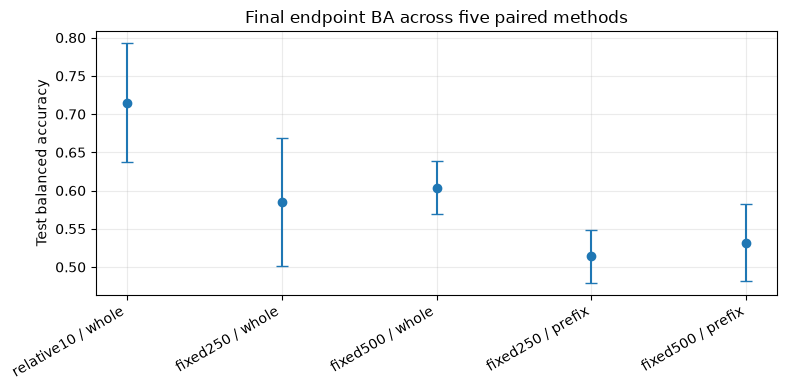

In [3]:
display(summary)
fig, ax = plt.subplots(figsize=(8, 4))
labels = summary['representation'] + ' / ' + summary['supervision']
ax.errorbar(np.arange(len(summary)), summary['mean_test_ba'], yerr=summary['sd_test_ba'], fmt='o', capsize=4)
ax.set_xticks(np.arange(len(summary)), labels, rotation=30, ha='right')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Final endpoint BA across five paired methods')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Paired prefix gains and oracle gaps


,split_seed,fixed250_whole,fixed250_prefix,delta250,fixed500_whole,fixed500_prefix,delta500,relative10_whole,gap250,gap500
0,11,0.683184,0.572992,-0.110192,0.647699,0.572038,-0.075660,0.817824,0.244833,0.245786
1,23,0.537563,0.500807,-0.036756,0.571126,0.542953,-0.028173,0.683647,0.182839,0.140693
2,37,0.610290,0.508009,-0.102282,0.588104,0.583701,-0.004403,0.728622,0.220613,0.144921
3,53,0.466443,0.484800,0.018357,0.633159,0.462898,-0.170260,0.605478,0.120678,0.142580
4,71,0.626929,0.502547,-0.124381,0.578741,0.498319,-0.080421,0.738127,0.235580,0.239808


,duration,mean_delta,sd_delta,positive_splits
0,Fixed250,-0.071051,0.060252,1
1,Fixed500,-0.071784,0.063697,0


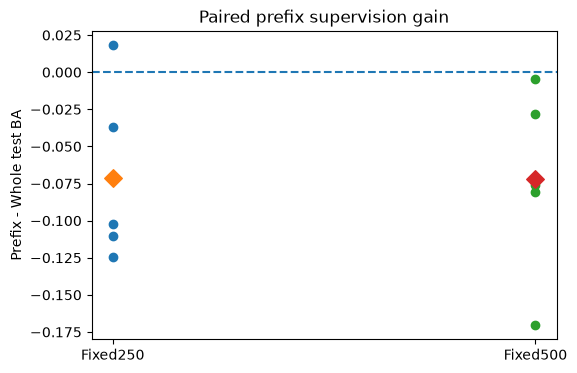

In [4]:
display(paired)
delta_summary = pd.DataFrame({
    'duration': ['Fixed250', 'Fixed500'],
    'mean_delta': [paired.delta250.mean(), paired.delta500.mean()],
    'sd_delta': [paired.delta250.std(ddof=1), paired.delta500.std(ddof=1)],
    'positive_splits': [(paired.delta250 > 0).sum(), (paired.delta500 > 0).sum()],
})
display(delta_summary)
fig, ax = plt.subplots(figsize=(6, 4))
for x, col in enumerate(['delta250', 'delta500']):
    ax.scatter(np.full(len(paired), x), paired[col])
    ax.scatter([x], [paired[col].mean()], marker='D', s=80)
ax.axhline(0, linestyle='--')
ax.set_xticks([0, 1], ['Fixed250', 'Fixed500'])
ax.set_ylabel('Prefix - Whole test BA')
ax.set_title('Paired prefix supervision gain')
plt.show()


## Streaming curves
Active curves only include gestures that reach the current duration and therefore always report `n_samples` and coverage. Endpoint-aware curves carry completed gestures' endpoint predictions forward.


,representation,training_mode,time_ms,mean_ba,sd_ba,mean_n,mean_coverage
0,fixed250,prefix,250.0,0.153717,0.032779,172.600000,1.000000
1,fixed250,prefix,500.0,0.253433,0.043704,172.600000,1.000000
2,fixed250,prefix,750.0,0.340203,0.080984,172.600000,1.000000
3,fixed250,prefix,1000.0,0.418741,0.062643,170.200000,0.986581
4,fixed250,prefix,1250.0,0.473108,0.066757,148.800000,0.864838
5,fixed250,prefix,1500.0,0.480537,0.071746,114.600000,0.667450
6,fixed250,prefix,1750.0,0.498970,0.188199,67.600000,0.400516
7,fixed250,prefix,2000.0,0.474044,0.116109,31.200000,0.192024
8,fixed250,prefix,2250.0,0.589167,0.230857,12.800000,0.082794
9,fixed250,prefix,2500.0,0.522222,0.252946,7.666667,0.051460


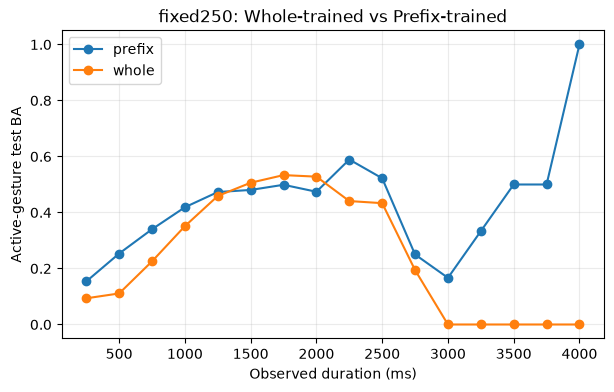

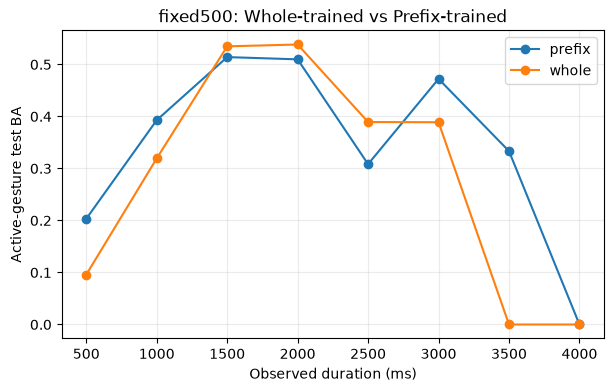

In [5]:
test_active = curves[(curves.cohort == 'test') & (curves.curve_type == 'active')].copy()
agg = test_active.groupby(['representation', 'training_mode', 'time_ms'], as_index=False).agg(
    mean_ba=('balanced_accuracy', 'mean'), sd_ba=('balanced_accuracy', 'std'),
    mean_n=('n_samples', 'mean'), mean_coverage=('coverage', 'mean'))
display(agg)
for representation in ['fixed250', 'fixed500']:
    fig, ax = plt.subplots(figsize=(7, 4))
    subset = agg[agg.representation == representation]
    for mode, group in subset.groupby('training_mode', sort=False):
        ax.plot(group.time_ms, group.mean_ba, marker='o', label=mode)
    ax.set_xlabel('Observed duration (ms)')
    ax.set_ylabel('Active-gesture test BA')
    ax.set_title(f'{representation}: Whole-trained vs Prefix-trained')
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()


## Cross-duration comparison and validation-standard decision


In [6]:
common = agg[(agg.training_mode == 'prefix') & (agg.time_ms.isin([500.0, 1000.0, 1500.0, 2000.0]))]
display(common)
primary_supported = bool((paired.delta250.mean() > 0) and ((paired.delta250 > 0).sum() >= 4))
decision = pd.DataFrame([{
    'mean_delta250': paired.delta250.mean(),
    'sd_delta250': paired.delta250.std(ddof=1),
    'positive_delta250_splits': int((paired.delta250 > 0).sum()),
    'primary_hypothesis_supported': primary_supported,
    'mean_gap250': paired.gap250.mean(),
    'mean_gap500': paired.gap500.mean(),
}])
display(decision)


,representation,training_mode,time_ms,mean_ba,sd_ba,mean_n,mean_coverage
1,fixed250,prefix,500.0,0.253433,0.043704,172.6,1.000000
3,fixed250,prefix,1000.0,0.418741,0.062643,170.2,0.986581
5,fixed250,prefix,1500.0,0.480537,0.071746,114.6,0.667450
7,fixed250,prefix,2000.0,0.474044,0.116109,31.2,0.192024
32,fixed500,prefix,500.0,0.203264,0.024636,172.6,1.000000
33,fixed500,prefix,1000.0,0.392878,0.054136,172.6,1.000000
34,fixed500,prefix,1500.0,0.514133,0.067792,148.8,0.864838
35,fixed500,prefix,2000.0,0.509818,0.140740,67.6,0.400516


,mean_delta250,sd_delta250,positive_delta250_splits,primary_hypothesis_supported,mean_gap250,mean_gap500
0,-0.071051,0.060252,1,False,0.200909,0.182757


## Conclusion and next experiment
If Fixed250 Prefix has positive mean paired gain and at least 4/5 positive splits, the next SNN experiment can reuse the same Fixed250 cumulative-prefix supervision. If both Fixed250 and Fixed500 Prefix fail to improve their Whole controls, supervision timing is unlikely to be the main raw-representation bottleneck and the next work should focus on SNN temporal dynamics/capacity instead.
